# Use Entire Dataset to Do KMeans, k = 2
* Entire Dataset
* Mean Imputation
* Z-Score Scaling
* K-Means
    * k = 2
    * Scatter Plot
    * Add Cluster Label
    * Check Each Cluster Distribution
    * Split Dataset: 80% Train / 20% Test
    * Noise Removal
    * Remove Cluster for later logistic regression
* Logistic Regression
    * Full model
    * Stepwise BIC model -- remove non-significant predictor variables
    * ROC curves

# Load Dataset

In [ ]:
# Load Dataset
data <- read.csv("../Pima-Indians-Diabetes-Dataset/diabetes.csv")
head(data)

Garnet <- rgb(107, 13, 14, maxColorValue = 255)
Gold   <- rgb(248, 194, 58, maxColorValue = 255)
garnet <- "#6B0D0E"
gold   <- "#F8C23A"


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
,<int>,<int>,<int>,<int>,<int>,<dbl>,<dbl>,<int>,<int>
1,6,148,72,35,0,33.6,0.627,50,1
2,1,85,66,29,0,26.6,0.351,31,0
3,8,183,64,0,0,23.3,0.672,32,1
4,1,89,66,23,94,28.1,0.167,21,0
5,0,137,40,35,168,43.1,2.288,33,1
6,5,116,74,0,0,25.6,0.201,30,0


# Mean Imputation

In [2]:
# ============================
# Check zeros before imputation
# ============================

cat("Zeros BEFORE imputation:\n")

colSums(
  data[, c(
    "Glucose",
    "BloodPressure",
    "SkinThickness",
    "Insulin",
    "BMI"
  )] == 0
)

# ============================
# Calculate means from Whole data
# ============================

mean_glucose_0 <- mean(data$Glucose[
  data$Outcome == 0 &
  data$Glucose != 0
])

mean_glucose_1 <- mean(data$Glucose[
  data$Outcome == 1 &
  data$Glucose != 0
])

mean_bp_0 <- mean(data$BloodPressure[
  data$Outcome == 0 &
  data$BloodPressure != 0
])

mean_bp_1 <- mean(data$BloodPressure[
  data$Outcome == 1 &
  data$BloodPressure != 0
])

mean_skin_0 <- mean(data$SkinThickness[
  data$Outcome == 0 &
  data$SkinThickness != 0
])

mean_skin_1 <- mean(data$SkinThickness[
  data$Outcome == 1 &
  data$SkinThickness != 0
])

mean_insulin_0 <- mean(data$Insulin[
  data$Outcome == 0 &
  data$Insulin != 0
])

mean_insulin_1 <- mean(data$Insulin[
  data$Outcome == 1 &
  data$Insulin != 0
])

mean_bmi_0 <- mean(data$BMI[
  data$Outcome == 0 &
  data$BMI != 0
])

mean_bmi_1 <- mean(data$BMI[
  data$Outcome == 1 &
  data$BMI != 0
])

print("Glucose 0 & 1")
mean_glucose_0
mean_glucose_1

print("BloodPressure 0 & 1")
mean_bp_0
mean_bp_1

print("SkinThickness 0 & 1")
mean_skin_0
mean_skin_1

print("Insulin 0 & 1")
mean_insulin_0
mean_insulin_1

print("BMI 0 & 1")
mean_bmi_0
mean_bmi_1

# ============================
# Impute Whole dataset
# ============================
# Glucose
data$Glucose[data$Outcome == 0 & data$Glucose == 0] <- mean_glucose_0
data$Glucose[data$Outcome == 1 & data$Glucose == 0] <- mean_glucose_1

# BloodPressure
data$BloodPressure[data$Outcome == 0 & data$BloodPressure == 0] <- mean_bp_0
data$BloodPressure[data$Outcome == 1 & data$BloodPressure == 0] <- mean_bp_1

# SkinThickness
data$SkinThickness[data$Outcome == 0 & data$SkinThickness == 0] <- mean_skin_0
data$SkinThickness[data$Outcome == 1 & data$SkinThickness == 0] <- mean_skin_1

# Insulin
data$Insulin[data$Outcome == 0 & data$Insulin == 0] <- mean_insulin_0
data$Insulin[data$Outcome == 1 & data$Insulin == 0] <- mean_insulin_1

# BMI
data$BMI[data$Outcome == 0 & data$BMI == 0] <- mean_bmi_0
data$BMI[data$Outcome == 1 & data$BMI == 0] <- mean_bmi_1

# ============================
# Check zeros after imputation
# ============================

cat("\nZeros AFTER imputation:\n")

colSums(
  data[, c(
    "Glucose",
    "BloodPressure",
    "SkinThickness",
    "Insulin",
    "BMI"
  )] == 0
)

Zeros BEFORE imputation:


Glucose BloodPressure SkinThickness       Insulin           BMI 
            5            35           227           374            11

[1] "Glucose 0 & 1"


[1] 110.6439

[1] 142.3195

...

[1] "BMI 0 & 1"


[1] 30.85967

[1] 35.40677


Zeros AFTER imputation:


Glucose BloodPressure SkinThickness       Insulin           BMI 
            0             0             0             0             0

# Z-Score Scaling

In [3]:
data_clean <- data
head(data_clean) # After Mean Imputation Dataset

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<int>,<int>
1,6,148,72,35.00000,206.8462,33.6,0.627,50,1
2,1,85,66,29.00000,130.2879,26.6,0.351,31,0
3,8,183,64,33.00000,206.8462,23.3,0.672,32,1
4,1,89,66,23.00000,94.0000,28.1,0.167,21,0
5,0,137,40,35.00000,168.0000,43.1,2.288,33,1
6,5,116,74,27.23546,130.2879,25.6,0.201,30,0


In [4]:
str(data_clean)

'data.frame':	768 obs. of  9 variables:
 $ Pregnancies             : int  6 1 8 1 0 5 3 10 2 8 ...
 $ Glucose                 : num  148 85 183 89 137 116 78 115 197 125 ...
 $ BloodPressure           : num  72 66 64 66 40 ...
 $ SkinThickness           : num  35 29 33 23 35 ...
 $ Insulin                 : num  207 130 207 94 168 ...
 $ BMI                     : num  33.6 26.6 23.3 28.1 43.1 ...
 $ DiabetesPedigreeFunction: num  0.627 0.351 0.672 0.167 2.288 ...
 $ Age                     : int  50 31 32 21 33 30 26 29 53 54 ...
 $ Outcome                 : int  1 0 1 0 1 0 1 0 1 1 ...


In [5]:
X <- data_clean[, names(data_clean) != "Outcome"]

Y <- data_clean$Outcome

In [6]:
X_scaled <- scale(X)

In [7]:
data_scaled <- data.frame(
  X_scaled,
  Outcome = Y
)

In [8]:
summary(data_scaled)

  Pregnancies         Glucose        BloodPressure      SkinThickness    
 Min.   :-1.1411   Min.   :-2.5506   Min.   :-4.00033   Min.   :-2.4930  
 1st Qu.:-0.8443   1st Qu.:-0.7205   1st Qu.:-0.69619   1st Qu.:-0.4759  
 Median :-0.2508   Median :-0.1542   Median :-0.03537   Median :-0.1397  
 Mean   : 0.0000   Mean   : 0.0000   Mean   : 0.00000   Mean   : 0.0000  
 3rd Qu.: 0.6395   3rd Qu.: 0.6337   3rd Qu.: 0.62546   3rd Qu.: 0.4206  
 Max.   : 3.9040   Max.   : 2.5377   Max.   : 4.09480   Max.   : 7.8164  
    Insulin             BMI           DiabetesPedigreeFunction
 Min.   :-1.6093   Min.   :-2.07101   Min.   :-1.1888         
 1st Qu.:-0.3995   1st Qu.:-0.71906   1st Qu.:-0.6885         
 Median :-0.3006   Median :-0.05763   Median :-0.2999         
 Mean   : 0.0000   Mean   : 0.00000   Mean   : 0.0000         
 3rd Qu.: 0.5609   3rd Qu.: 0.60381   3rd Qu.: 0.4659         
 Max.   : 7.7537   Max.   : 5.03761   Max.   : 5.8797         
      Age             Outcome     
 Min. 

# K-Means

### k = 2

In [9]:
k = 2

In [10]:
set.seed(123)

kmeans_model <- kmeans(
  X_scaled,
  centers = k,
  nstart = 25
)

### Scatter Plot
* Use PCA to reduce dimensionality, because a scatter plot can only display two dimensions.


In [11]:
pca <- prcomp(
  X_scaled,
  center = FALSE,
  scale. = FALSE
)

In [12]:
pca_df <- data.frame(
  PC1 = pca$x[,1],
  PC2 = pca$x[,2],
  Cluster = factor(kmeans_model$cluster),
  Outcome = factor(Y)
)

#### K-means group

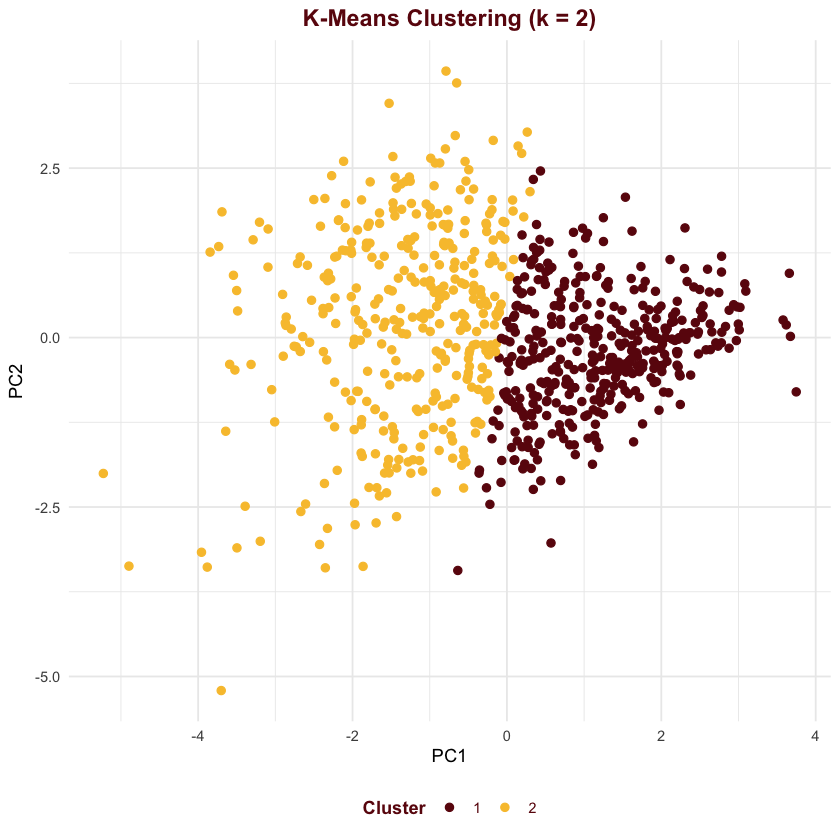

In [13]:
library(ggplot2)
ggplot(
  pca_df,
  aes(
    x = PC1,
    y = PC2,
    color = Cluster
  )
) +

  geom_point(size = 2) +

  scale_color_manual(
    values = c(
      "1" = Garnet,
      "2" = Gold
    )
  ) +

  labs(
    title = "K-Means Clustering (k = 2)",
    color = "Cluster"
  ) +

  theme_minimal() +

  theme(
    plot.title = element_text(
      face = "bold",
      color = Garnet,
      hjust = 0.5,
      size = 14
    ),
    legend.position = "bottom",
    legend.title = element_text(
      face = "bold",
      color = Garnet
    ),
    legend.text = element_text(
      color = Garnet
    )
  )

#### Actual Diabetes Status

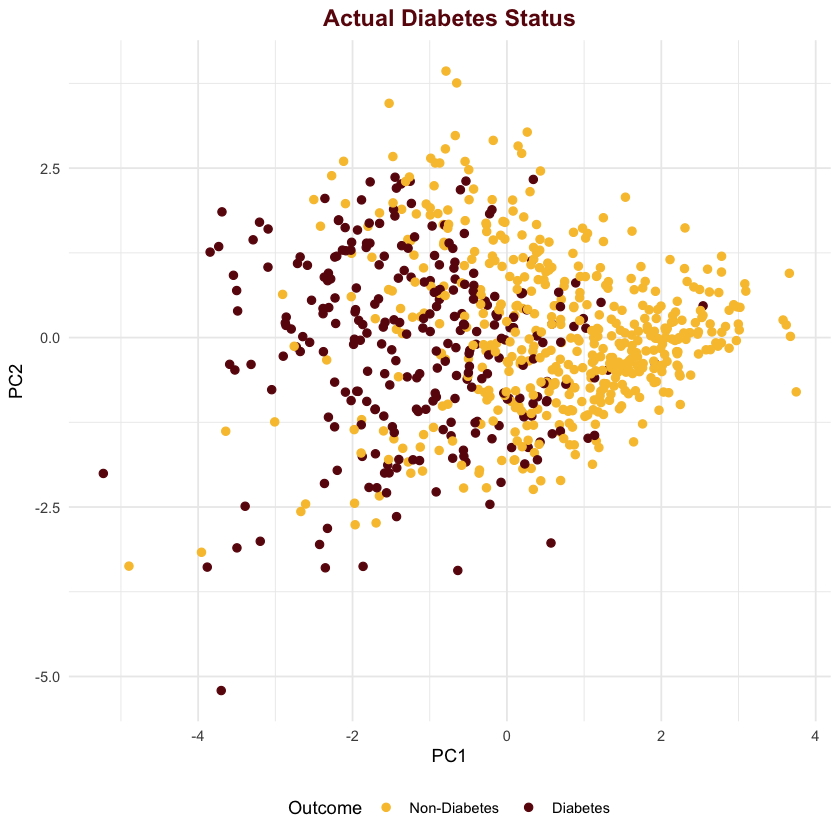

In [14]:
ggplot(
  pca_df,
  aes(
    x = PC1,
    y = PC2,
    color = Outcome
  )
) +
scale_color_manual(
      values = c(
        "0" = Gold,
        "1" = Garnet
      ),
      labels = c(
        "Non-Diabetes",
        "Diabetes"
      )
    ) +
  geom_point(size = 2) +
  labs(
    title = "Actual Diabetes Status"
  ) +
  theme_minimal() +
  theme(
      plot.title = element_text(
        face = "bold",
        color = Garnet,
        hjust = 0.5,
        size = 14
      ),
      legend.position = "bottom"
    )

#### Cluster VS Actual Diabets Status

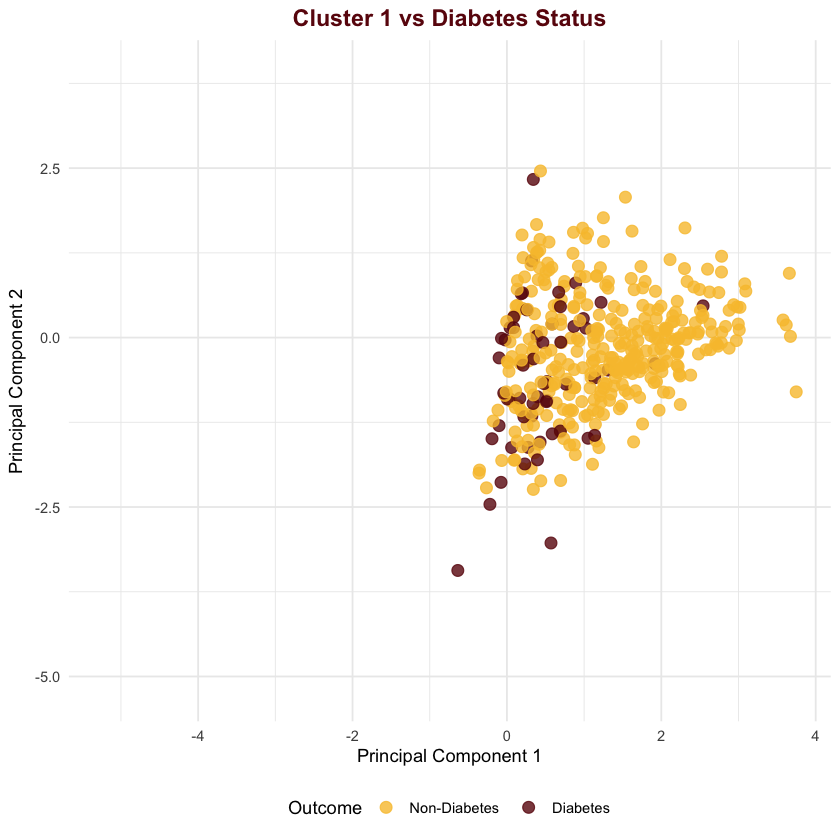

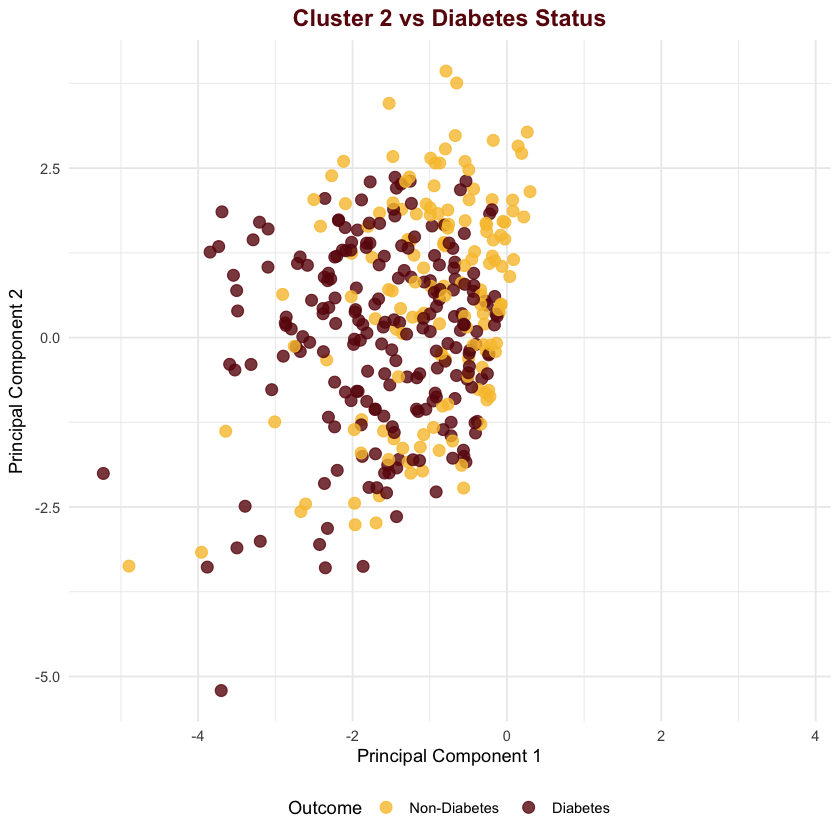

In [15]:
x_range <- range(pca_df$PC1)
y_range <- range(pca_df$PC2)

for(i in 1:2)
{
  
  p <- ggplot(
    subset(pca_df, Cluster == i),
    aes(
      x = PC1,
      y = PC2,
      color = Outcome
    )
  ) +
    geom_point(
      size = 3,
      alpha = 0.8
    ) +
    scale_color_manual(
      values = c(
        "0" = Gold,
        "1" = Garnet
      ),
      labels = c(
        "Non-Diabetes",
        "Diabetes"
      )
    ) +
    labs(
      title = paste(
        "Cluster",
        i,
        "vs Diabetes Status"
      ),
      x = "Principal Component 1",
      y = "Principal Component 2",
      color = "Outcome"
    ) +
    theme_minimal() +
    theme(
      plot.title = element_text(
        face = "bold",
        color = Garnet,
        hjust = 0.5,
        size = 14
      ),
      legend.position = "bottom"
    ) + 
    coord_cartesian(
      xlim = x_range,
      ylim = y_range
    )
  
  print(p)
}

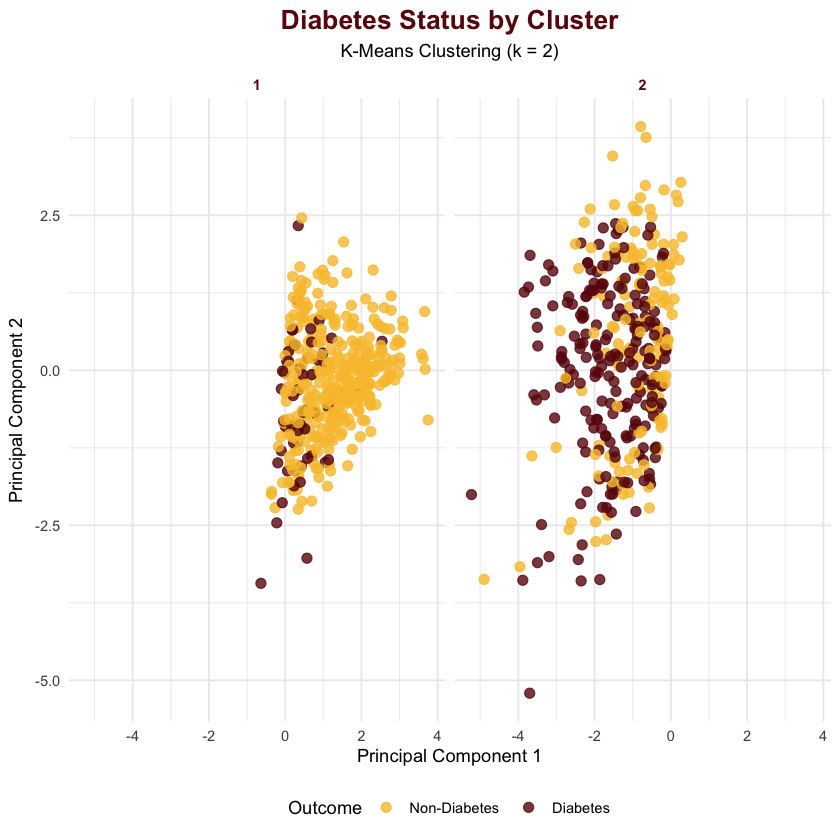

In [16]:
ggplot(
  pca_df,
  aes(
    PC1,
    PC2,
    color = Outcome
  )
) +
  geom_point(
    size = 2.5,
    alpha = 0.8
  ) +
  facet_wrap(
    ~ Cluster,
    ncol = 5
  ) +
  scale_color_manual(
    values = c(
      "0" = Gold,
      "1" = Garnet
    ),
    labels = c(
      "Non-Diabetes",
      "Diabetes"
    )
  ) +
  labs(
    title = "Diabetes Status by Cluster",
    subtitle = "K-Means Clustering (k = 2)",
    x = "Principal Component 1",
    y = "Principal Component 2",
    color = "Outcome"
  ) +
  theme_minimal() +
  theme(
    plot.title = element_text(
      face = "bold",
      size = 16,
      hjust = 0.5,
      color = Garnet
    ),
    plot.subtitle = element_text(
      hjust = 0.5
    ),
    strip.text = element_text(
      face = "bold",
      color = Garnet
    ),
    theme(
      strip.background = element_rect(
        fill = Gold,
        color = Garnet
      ),
      strip.text = element_text(
        face = "bold",
        color = Garnet
      )
    ),
    legend.position = "bottom"
  )

### Add Cluster Label

In [17]:
data_clustered <- data.frame(
  data_scaled,
  Cluster = kmeans_model$cluster
)

In [18]:
head(data_clustered)

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome,Cluster
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<int>,<int>
1,0.6395305,0.8634573,-0.03536589,0.6446679,0.5609061,0.1676966,0.4681869,1.42506672,1,2
2,-0.8443348,-1.2046927,-0.53098610,-0.0276832,-0.3006457,-0.8498977,-0.3648230,-0.19054773,0,1
3,1.2330766,2.0124295,-0.69619284,0.4205509,0.5609061,-1.3296207,0.6040037,-0.10551539,1,2
4,-0.8443348,-1.0733816,-0.53098610,-0.7000343,-0.7090128,-0.6318417,-0.9201630,-1.04087112,0,1
5,-1.1411079,0.5023517,-2.67867369,0.6446679,0.1237493,1.5487174,5.4813370,-0.02048305,1,1
6,0.3427574,-0.1870316,0.12984085,-0.2254153,-0.3006457,-0.9952683,-0.8175458,-0.27558007,0,1


### Check Each Cluster Distribution

In [19]:
cluster_summary <- table(
  data_clustered$Cluster,
  data_clustered$Outcome
)

cluster_summary

   
      0   1
  1 351  56
  2 149 212

### Split Dataset First

In [20]:
set.seed(123)

index <- sample(
  1:nrow(data_clustered),
  size = 0.8 * nrow(data_clustered)
)

train_data <- data_clustered[index, ]
test_data  <- data_clustered[-index, ]

### Noise Removal

In [21]:
# clean_clusters <- list()

# for(i in unique(train_data$Cluster))
# {
  
#   cluster_data <- subset(
#     train_data,
#     Cluster == i
#   )
  
#   class_count <- table(
#     cluster_data$Outcome
#   )
  
#   majority_class <- names(
#     which.max(class_count)
#   )
  
#   clean_clusters[[as.character(i)]] <- subset(
#     cluster_data,
#     Outcome == majority_class
#   )
# }

clean_clusters <- list()

predictors <- names(train_data)[
  !(names(train_data) %in%
      c("Outcome","Cluster"))
]

for(i in unique(train_data$Cluster))
{
  
  cluster_data <- subset(
    train_data,
    Cluster == i
  )
  
  center <- kmeans_model$centers[i, ]
  
  distances <- apply(
    cluster_data[, predictors],
    1,
    function(x)
      sqrt(sum((x - center)^2))
  )
  
  cutoff <- quantile(
    distances,
    0.95
  )
  
  clean_clusters[[as.character(i)]] <-
    cluster_data[
      distances <= cutoff,
    ]
}

### Merging Data

In [22]:
train_clean <- do.call(
  rbind,
  clean_clusters
)

row.names(train_clean) <- NULL

### Check Removed Data

In [23]:
cat(
  "Original Train Size:",
  nrow(train_data),
  "\n"
)

cat(
  "Clean Train Size:",
  nrow(train_clean),
  "\n"
)

cat(
  "Removed:",
  nrow(train_data) -
    nrow(train_clean),
  "\n"
)

Original Train Size: 614 


Clean Train Size: 583 
Removed: 31 


### Remove Cluster

In [24]:
train_clean <- subset(
  train_clean,
  select = -Cluster
)

test_data <- subset(
  test_data,
  select = -Cluster
)

# Logistic Regression

In [25]:
model_logistic <- glm(
  Outcome ~ .,
  data = train_clean,
  family = binomial
)

summary(model_logistic)


Call:
glm(formula = Outcome ~ ., family = binomial, data = train_clean)

Coefficients:
                         Estimate Std. Error z value Pr(>|z|)    
(Intercept)               -0.8294     0.1192  -6.960 3.40e-12 ***
Pregnancies                0.3388     0.1265   2.677  0.00742 ** 
Glucose                    0.9273     0.1455   6.372 1.86e-10 ***
BloodPressure             -0.1325     0.1344  -0.986  0.32431    
SkinThickness              0.3253     0.1507   2.158  0.03095 *  
Insulin                    1.1865     0.2080   5.705 1.16e-08 ***
BMI                        0.3136     0.1524   2.058  0.03959 *  
DiabetesPedigreeFunction   0.2947     0.1246   2.365  0.01805 *  
Age                        0.1154     0.1350   0.854  0.39287    
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

(Dispersion parameter for binomial family taken to be 1)

    Null deviance: 752.35  on 582  degrees of freedom
Residual deviance: 489.01  on 574  degrees of freedom
AIC: 507.01

Numbe

In [26]:
# ============================
# Prediction (Train)
# ============================

prob_train <- predict(
  model_logistic,
  newdata = train_clean,
  type = "response"
)

pred_train <- ifelse(
  prob_train > 0.42,
  1,
  0
)

# ============================
# Confusion Matrix (Train)
# ============================

cm_train <- table(
  Actual = train_clean$Outcome,
  Predicted = pred_train
)

print(cm_train)

# ============================
# Evaluation Metrics (Train)
# ============================

accuracy_train <- sum(diag(cm_train)) /
  sum(cm_train)

TP_train <- cm_train["1", "1"]
TN_train <- cm_train["0", "0"]
FP_train <- cm_train["0", "1"]
FN_train <- cm_train["1", "0"]

precision_train <- TP_train /
  (TP_train + FP_train)

recall_train <- TP_train /
  (TP_train + FN_train)

f1_train <- 2 *
  precision_train *
  recall_train /
  (precision_train + recall_train)

# ============================
# Results (Train)
# ============================

cat(
  "\nTraining Data Outcome:",
  "\nAccuracy =", round(accuracy_train, 4),
  "\nPrecision =", round(precision_train, 4),
  "\nRecall =", round(recall_train, 4),
  "\nF1 Score =", round(f1_train, 4)
)

      Predicted
Actual   0   1
     0 332  49
     1  48 154

Training Data Outcome: 
Accuracy = 0.8336 
Precision = 0.7586 
Recall = 0.7624 
F1 Score = 0.7605

In [27]:
# prob <- predict(
#   model_logistic,
#   newdata = test_data,
#   type = "response"
# )

# pred <- ifelse(prob > 0.42, 1, 0)

In [28]:
# cm <- table(
#   Actual = test_data$Outcome,
#   Predicted = pred
# )

# cm

In [29]:
# TN <- cm[1,1]
# FP <- cm[1,2]
# FN <- cm[2,1]
# TP <- cm[2,2]

# accuracy <- (TP + TN) /
#             sum(cm)

# precision <- TP /
#                (TP + FP)

# recall <- TP /
#                (TP + FN)

# f1 <- 2 * precision * recall /
#                (precision + recall)

# cat(
#   "Testing data outcome:",
#   "\nAccuracy =", round(accuracy,4), "\n"
# )

# cat(
#   "Precision =", round(precision,4), "\n"
# )

# cat(
#   "Recall =", round(recall,4), "\n"
# )

# cat(
#   "F-1 Score =", round(f1,4), "\n"
# )

In [30]:
BIC(model_logistic)

[1] 546.3189

### Handel p-value

In [31]:
# model_1 <- glm(
#   Outcome ~ . - Age - Pregnancies,
#   data = train_clean,
#   family = binomial
# )

# summary(model_1)
# BIC(model_1)

In [32]:
full_model <- glm(
  Outcome ~ .,
  data = train_clean,
  family = binomial
)

step_model <- step(
  full_model,
  direction = "backward",
  k = log(nrow(train_clean))
)

Start:  AIC=546.32
Outcome ~ Pregnancies + Glucose + BloodPressure + SkinThickness + 
    Insulin + BMI + DiabetesPedigreeFunction + Age

                           Df Deviance    AIC
- Age                       1   489.73 540.68
- BloodPressure             1   489.98 540.93
- BMI                       1   493.31 544.26
- SkinThickness             1   493.73 544.67
- DiabetesPedigreeFunction  1   494.65 545.59
<none>                          489.01 546.32
- Pregnancies               1   496.34 547.29
- Insulin                   1   529.60 580.55
- Glucose                   1   534.93 585.88

Step:  AIC=540.68
Outcome ~ Pregnancies + Glucose + BloodPressure + SkinThickness + 
    Insulin + BMI + DiabetesPedigreeFunction

                           Df Deviance    AIC
- BloodPressure             1   490.33 534.91
- BMI                       1   493.54 538.12
- SkinThickness             1   494.63 539.21
- DiabetesPedigreeFunction  1   495.65 540.23
<none>                          489.73 5

In [33]:
summary(step_model)

BIC(step_model)

BIC(full_model)


Call:
glm(formula = Outcome ~ Pregnancies + Glucose + SkinThickness + 
    Insulin, family = binomial, data = train_clean)

Coefficients:
              Estimate Std. Error z value Pr(>|z|)    
(Intercept)    -0.8296     0.1177  -7.047 1.83e-12 ***
Pregnancies     0.3543     0.1066   3.323 0.000890 ***
Glucose         0.9544     0.1401   6.813 9.54e-12 ***
SkinThickness   0.4573     0.1336   3.422 0.000621 ***
Insulin         1.3056     0.2080   6.277 3.46e-10 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

(Dispersion parameter for binomial family taken to be 1)

    Null deviance: 752.35  on 582  degrees of freedom
Residual deviance: 499.93  on 578  degrees of freedom
AIC: 509.93

Number of Fisher Scoring iterations: 5


[1] 531.7697

[1] 546.3189

### ROC Curve

In [34]:
# Full Model
prob_full <- predict(
  model_logistic,
  newdata = test_data,
  type = "response"
)

# Stepwise BIC Model
prob_step <- predict(
  step_model,
  newdata = test_data,
  type = "response"
)

In [35]:
summary(step_model)

BIC(step_model)

BIC(full_model)


Call:
glm(formula = Outcome ~ Pregnancies + Glucose + SkinThickness + 
    Insulin, family = binomial, data = train_clean)

Coefficients:
              Estimate Std. Error z value Pr(>|z|)    
(Intercept)    -0.8296     0.1177  -7.047 1.83e-12 ***
Pregnancies     0.3543     0.1066   3.323 0.000890 ***
Glucose         0.9544     0.1401   6.813 9.54e-12 ***
SkinThickness   0.4573     0.1336   3.422 0.000621 ***
Insulin         1.3056     0.2080   6.277 3.46e-10 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

(Dispersion parameter for binomial family taken to be 1)

    Null deviance: 752.35  on 582  degrees of freedom
Residual deviance: 499.93  on 578  degrees of freedom
AIC: 509.93

Number of Fisher Scoring iterations: 5


[1] 531.7697

[1] 546.3189

In [36]:
prob <- predict(
  step_model,
  newdata = test_data,
  type = "response"
)

pred <- ifelse(prob > 0.42, 1, 0)

In [37]:
cm <- table(
  Actual = test_data$Outcome,
  Predicted = pred
)

cm

      Predicted
Actual  0  1
     0 89 13
     1 15 37

In [38]:
TN <- cm[1,1]
FP <- cm[1,2]
FN <- cm[2,1]
TP <- cm[2,2]

accuracy <- (TP + TN) /
            sum(cm)

precision <- TP /
               (TP + FP)

recall <- TP /
               (TP + FN)

f1 <- 2 * precision * recall /
               (precision + recall)

cat(
  "Testing data outcome:",
  "\nAccuracy =", round(accuracy,4), "\n"
)

cat(
  "Precision =", round(precision,4), "\n"
)

cat(
  "Recall =", round(recall,4), "\n"
)

cat(
  "F-1 Score =", round(f1,4), "\n"
)

Testing data outcome: 
Accuracy = 0.8182 
Precision = 0.74 
Recall = 0.7115 
F-1 Score = 0.7255 


In [39]:
library(pROC)

roc_full <- roc(
  response = test_data$Outcome,
  predictor = prob_full
)

roc_step <- roc(
  response = test_data$Outcome,
  predictor = prob_step
)

Type 'citation("pROC")' for a citation.


Attaching package: ‘pROC’


The following objects are masked from ‘package:stats’:

    cov, smooth, var


Setting levels: control = 0, case = 1

Setting direction: controls < cases

Setting levels: control = 0, case = 1

Setting direction: controls < cases



In [40]:
auc(roc_full)

auc(roc_step)

Area under the curve: 0.8816

Area under the curve: 0.8675

In [41]:
roc.test(
  roc_full,
  roc_step
)


	DeLong's test for two correlated ROC curves

data:  roc_full and roc_step
Z = 1.2419, p-value = 0.2143
alternative hypothesis: true difference in AUC is not equal to 0
95 percent confidence interval:
 -0.008175199  0.036455742
sample estimates:
AUC of roc1 AUC of roc2 
  0.8815988   0.8674585 


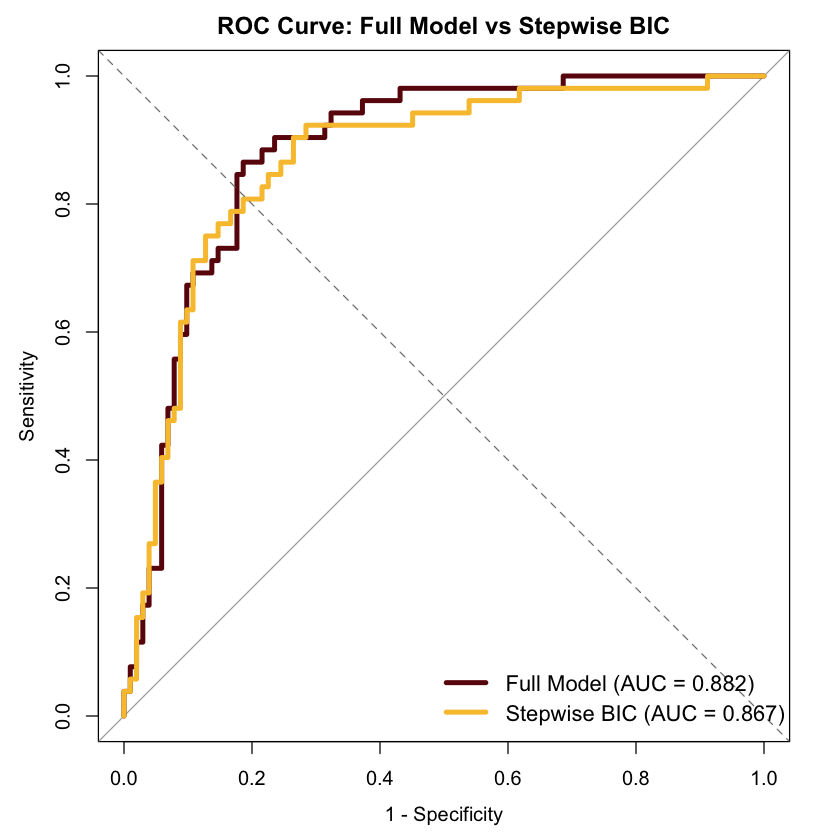

In [42]:
par(bg = "White")

plot(
  roc_full,
  col = Garnet,
  lwd = 4,
  legacy.axes = TRUE,
  main = "ROC Curve: Full Model vs Stepwise BIC"
)

plot(
  roc_step,
  add = TRUE,
  col = Gold,
  lwd = 4
)

abline(
  0,
  1,
  lty = 2,
  col = "gray50"
)

legend(
  "bottomright",
  legend = c(
    paste0(
      "Full Model (AUC = ",
      round(auc(roc_full), 3),
      ")"
    ),
    paste0(
      "Stepwise BIC (AUC = ",
      round(auc(roc_step), 3),
      ")"
    )
  ),
  col = c(Garnet, Gold),
  lwd = 4,
  cex = 1.1,
  bty = "n"
)

Results

<!-- #### Results, k = 10
* Full model: AUC=0.876, Stepwise BIC: AUC=0.872, the model demonstrated good discriminatory ability with an AUC of approximately 0.88.
* After remove those non-significant predictor variables (Age, BloodPressure, and DiabetesPedigreeFunction) through BIC-based stepwise selection, the simplified logistic regression model achieved an AUC of 0.872, compared with 0.876 for the full model. The ROC curves of the two models were nearly identical, indicating that the removed variables contributed little to the model's predictive performance. Therefore, the reduced model was able to maintain comparable classification accuracy while improving model simplicity and interpretability. 
* According to the Parsimony Principle, when two models achieve similar predictive performance, the simpler model is generally preferred. Although the full logistic regression model achieved a slightly higher AUC (0.876) than the BIC-selected model (0.872), the difference was negligible. Therefore, the BIC-selected model is more desirable because it uses fewer predictor variables while maintaining nearly the same classification performance. A simpler model is easier to interpret, less computationally complex, and less prone to overfitting.
* The diagonal line in the ROC curve represents the performance of a random classifier with an AUC of 0.50. A model whose ROC curve lies close to this line has little or no ability to distinguish between diabetic and non-diabetic patients. In contrast, both the full model and the BIC-selected model have ROC curves that are substantially above the diagonal line, indicating that they possess strong discriminatory power and perform much better than random guessing. -->

### PAC
* No obvious overfitting
    * Accuracy gap only 2.19%
    * F1 gap 4.21%
* Better Recall than the previous threshold (0.7115 vs. 0.6346)
    * Since recall value reflect whether the model detect diabetic patients, therefore I changed the threshold value from 0.5 to 0.42
* Sample size Check

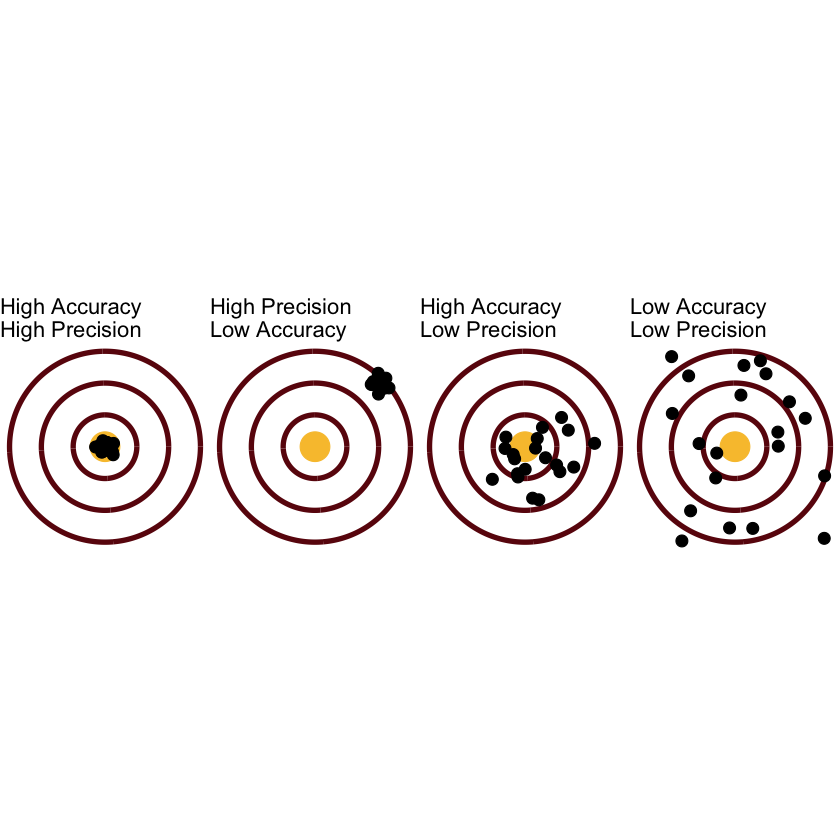

In [43]:
library(ggplot2)
library(gridExtra)

# Theme Colors
Garnet <- "#6B0D0E"
Gold <- "#F8C23A"

# Function to create target circles
target_base <- function() {

  theta <- seq(0, 2*pi, length.out = 500)

  circles <- rbind(
    data.frame(
      x = 3*cos(theta),
      y = 3*sin(theta),
      ring = "Outer"
    ),
    data.frame(
      x = 2*cos(theta),
      y = 2*sin(theta),
      ring = "Middle"
    ),
    data.frame(
      x = 1*cos(theta),
      y = 1*sin(theta),
      ring = "Inner"
    )
  )

  ggplot() +
    geom_path(
      data = subset(circles, ring=="Outer"),
      aes(x,y),
      color = Garnet,
      linewidth = 1.5
    ) +
    geom_path(
      data = subset(circles, ring=="Middle"),
      aes(x,y),
      color = Garnet,
      linewidth = 1.5
    ) +
    geom_path(
      data = subset(circles, ring=="Inner"),
      aes(x,y),
      color = Garnet,
      linewidth = 1.5
    ) +
    geom_point(
      aes(0,0),
      size = 8,
      color = Gold
    ) +
    coord_fixed() +
    theme_void()
}

set.seed(123)

# -----------------------
# High Accuracy High Precision
# -----------------------

ha_hp <- data.frame(
  x = rnorm(20,0,0.15),
  y = rnorm(20,0,0.15)
)

p1 <- target_base() +
  geom_point(
    data = ha_hp,
    aes(x,y),
    color = "black",
    size = 3
  ) +
  ggtitle("High Accuracy\nHigh Precision")

# -----------------------
# High Precision Low Accuracy
# -----------------------

hp_la <- data.frame(
  x = rnorm(20,2,0.15),
  y = rnorm(20,2,0.15)
)

p2 <- target_base() +
  geom_point(
    data = hp_la,
    aes(x,y),
    color = "black",
    size = 3
  ) +
  ggtitle("High Precision\nLow Accuracy")

# -----------------------
# High Accuracy Low Precision
# -----------------------

ha_lp <- data.frame(
  x = rnorm(20,0,1),
  y = rnorm(20,0,1)
)

p3 <- target_base() +
  geom_point(
    data = ha_lp,
    aes(x,y),
    color = "black",
    size = 3
  ) +
  ggtitle("High Accuracy\nLow Precision")

# -----------------------
# Low Accuracy Low Precision
# -----------------------

la_lp <- data.frame(
  x = runif(20,-3,3),
  y = runif(20,-3,3)
)

p4 <- target_base() +
  geom_point(
    data = la_lp,
    aes(x,y),
    color = "black",
    size = 3
  ) +
  ggtitle("Low Accuracy\nLow Precision")

# -----------------------
# Combine
# -----------------------

grid.arrange(
  p1,
  p2,
  p3,
  p4,
  ncol = 4
)

In [44]:
library(ggplot2)
library(gridExtra)

# Theme Colors
Garnet <- "#6B0D0E"
Gold <- "#F8C23A"

# Function to create target circles
target_base <- function() {

  theta <- seq(0, 2*pi, length.out = 500)

  circles <- rbind(
    data.frame(
      x = 3*cos(theta),
      y = 3*sin(theta),
      ring = "Outer"
    ),
    data.frame(
      x = 2*cos(theta),
      y = 2*sin(theta),
      ring = "Middle"
    ),
    data.frame(
      x = 1*cos(theta),
      y = 1*sin(theta),
      ring = "Inner"
    )
  )

  ggplot() +
    geom_path(
      data = subset(circles, ring=="Outer"),
      aes(x,y),
      color = Garnet,
      linewidth = 1.5
    ) +
    geom_path(
      data = subset(circles, ring=="Middle"),
      aes(x,y),
      color = Garnet,
      linewidth = 1.5
    ) +
    geom_path(
      data = subset(circles, ring=="Inner"),
      aes(x,y),
      color = Garnet,
      linewidth = 1.5
    ) +
    geom_point(
      aes(0,0),
      size = 8,
      color = Garnet
    ) +
    coord_fixed() +
    theme_void()
}

set.seed(123)

# -----------------------
# High Accuracy High Precision
# -----------------------

ha_hp <- data.frame(
  x = rnorm(20,0,0.15),
  y = rnorm(20,0,0.15)
)

p1 <- target_base() +
  geom_point(
    data = ha_hp,
    aes(x,y),
    color = Gold,
    size = 3
  ) +
  ggtitle("High Accuracy\nHigh Precision")

# -----------------------
# High Precision Low Accuracy
# -----------------------

hp_la <- data.frame(
  x = rnorm(20,2,0.15),
  y = rnorm(20,2,0.15)
)

p2 <- target_base() +
  geom_point(
    data = hp_la,
    aes(x,y),
    color = Gold,
    size = 3
  ) +
  ggtitle("High Precision\nLow Accuracy")

# -----------------------
# High Accuracy Low Precision
# -----------------------

ha_lp <- data.frame(
  x = rnorm(20,0,1),
  y = rnorm(20,0,1)
)

p3 <- target_base() +
  geom_point(
    data = ha_lp,
    aes(x,y),
    color = Gold,
    size = 3
  ) +
  ggtitle("High Accuracy\nLow Precision")

# -----------------------
# Low Accuracy Low Precision
# -----------------------

la_lp <- data.frame(
  x = runif(20,-3,3),
  y = runif(20,-3,3)
)

p4 <- target_base() +
  geom_point(
    data = la_lp,
    aes(x,y),
    color = Gold,
    size = 3
  ) +
  ggtitle("Low Accuracy\nLow Precision")

# -----------------------
# Combine
# -----------------------



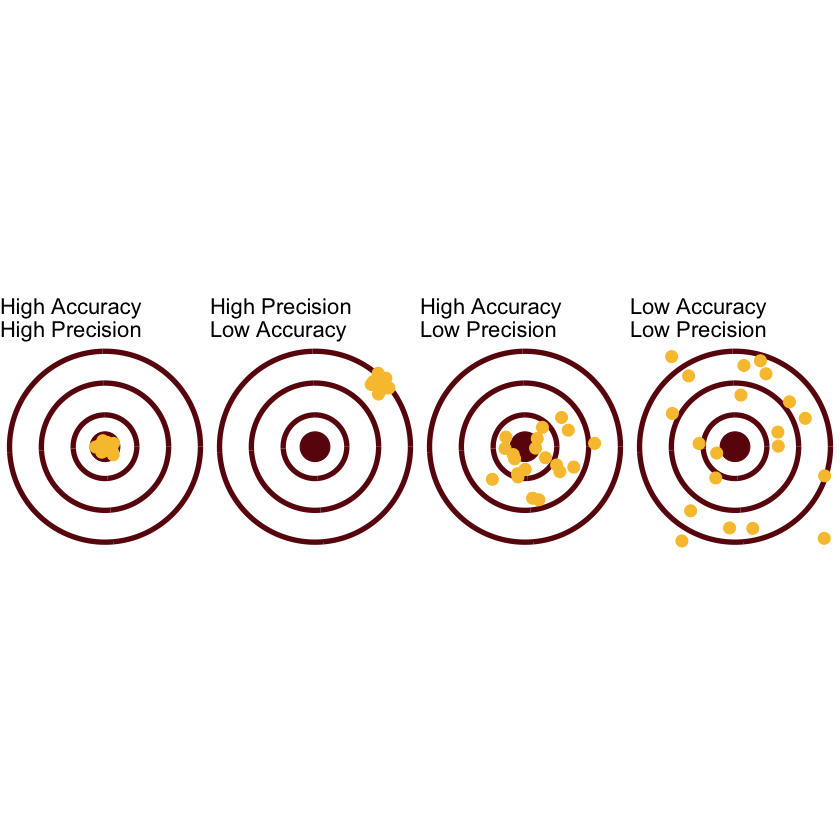

In [45]:
grid.arrange(
  p1,
  p2,
  p3,
  p4,
  ncol = 4
)

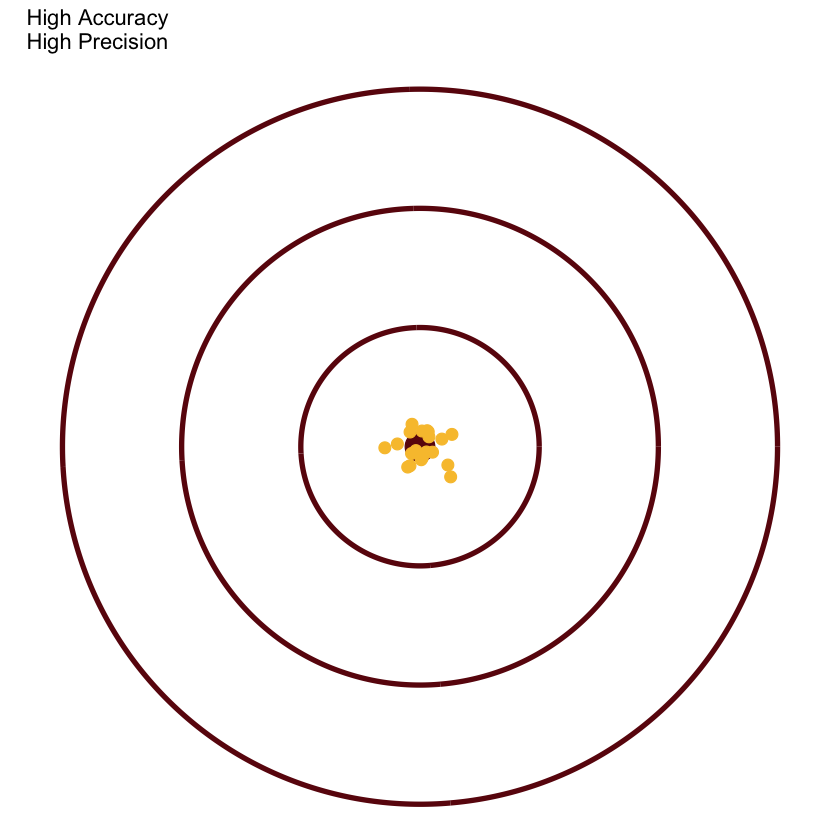

In [46]:
p1


Attaching package: ‘dplyr’


The following object is masked from ‘package:gridExtra’:

    combine


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union




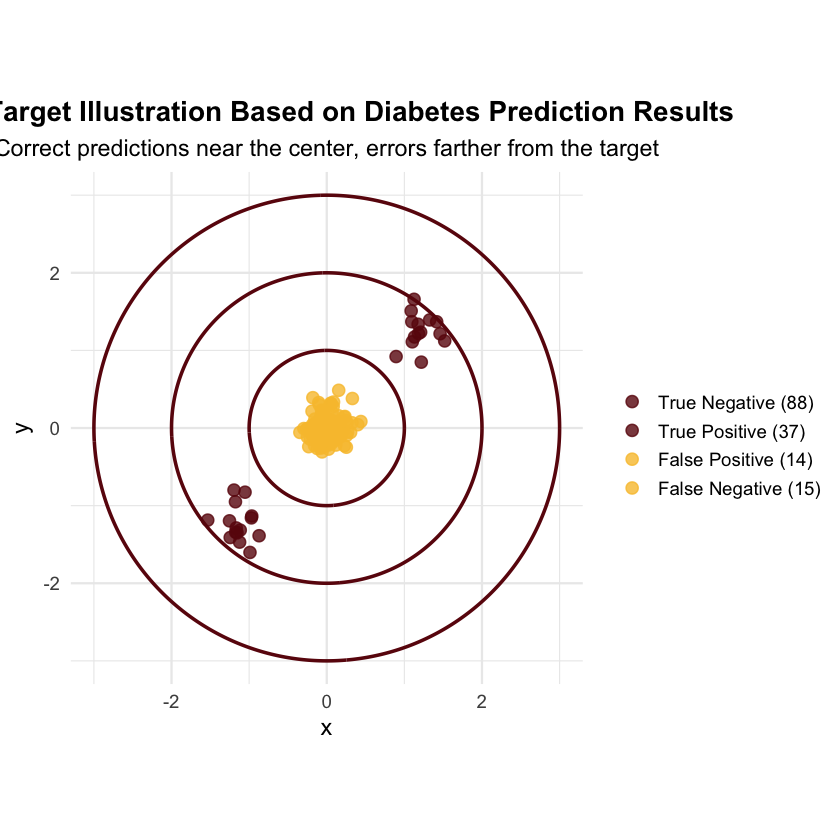

In [47]:
library(ggplot2)
library(dplyr)

Garnet <- "#6B0D0E"
Gold <- "#F8C23A"

set.seed(123)

# ============================
# Create points from confusion matrix
# ============================

TN <- data.frame(
  Type = "TN",
  x = rnorm(88, 0, 0.15),
  y = rnorm(88, 0, 0.15)
)

TP <- data.frame(
  Type = "TP",
  x = rnorm(37, 0, 0.20),
  y = rnorm(37, 0, 0.20)
)

FP <- data.frame(
  Type = "FP",
  x = rnorm(14, 1.2, 0.20),
  y = rnorm(14, 1.2, 0.20)
)

FN <- data.frame(
  Type = "FN",
  x = rnorm(15, -1.2, 0.20),
  y = rnorm(15, -1.2, 0.20)
)

target_data <- bind_rows(
  TN,
  TP,
  FP,
  FN
)

# ============================
# Target Rings
# ============================

theta <- seq(
  0,
  2*pi,
  length.out = 500
)

ring1 <- data.frame(
  x = cos(theta),
  y = sin(theta)
)

ring2 <- data.frame(
  x = 2*cos(theta),
  y = 2*sin(theta)
)

ring3 <- data.frame(
  x = 3*cos(theta),
  y = 3*sin(theta)
)

# ============================
# Plot
# ============================

ggplot() +

  geom_path(
    data = ring3,
    aes(x,y),
    color = Garnet,
    linewidth = 1
  ) +

  geom_path(
    data = ring2,
    aes(x,y),
    color = Garnet,
    linewidth = 1
  ) +

  geom_path(
    data = ring1,
    aes(x,y),
    color = Garnet,
    linewidth = 1
  ) +

  geom_point(
    aes(0,0),
    color = Gold,
    size = 8
  ) +

  geom_point(
    data = target_data,
    aes(
      x,
      y,
      color = Type
    ),
    size = 3,
    alpha = 0.8
  ) +

  scale_color_manual(
    values = c(
      "TN" = Gold,
      "TP" = Gold,
      "FP" = Garnet,
      "FN" = Garnet
    ),
    labels = c(
      "True Negative (88)",
      "True Positive (37)",
      "False Positive (14)",
      "False Negative (15)"
    )
  ) +

  coord_fixed() +

  labs(
    title = "PAC Target Illustration Based on Diabetes Prediction Results",
    subtitle = "Correct predictions near the center, errors farther from the target",
    color = ""
  ) +

  theme_minimal(base_size = 14) +

  theme(
    plot.title = element_text(
      face = "bold",
      hjust = 0.5
    ),
    plot.subtitle = element_text(
      hjust = 0.5
    )
  )

In [48]:
library(ggplot2)
library(gridExtra)

Garnet <- "#6B0D0E"
Gold <- "#F8C23A"

target_base <- function(){

  theta <- seq(
    0,
    2*pi,
    length.out = 500
  )

  ggplot() +

    geom_path(
      aes(
        3*cos(theta),
        3*sin(theta)
      ),
      color = Garnet
    ) +

    geom_path(
      aes(
        2*cos(theta),
        2*sin(theta)
      ),
      color = Garnet
    ) +

    geom_path(
      aes(
        cos(theta),
        sin(theta)
      ),
      color = Garnet
    ) +

    geom_point(
      aes(0,0),
      size = 10,
      color = Gold
    ) +

    coord_fixed() +

    xlim(-3.2,3.2) +
    ylim(-3.2,3.2) +

    theme_void()
}

In [49]:
set.seed(123)

TN <- data.frame(
  x = rnorm(
    88,
    0,
    0.25
  ),
  y = rnorm(
    88,
    0,
    0.25
  )
)

p_TN <- target_base() +

  geom_point(
    data = TN,
    aes(x,y),
    color = Gold,
    size = 2.5
  ) +

  labs(
    title = "True Negative (88)"
  )

In [50]:
FP <- data.frame(
  x = rnorm(
    14,
    2.2,
    0.30
  ),
  y = rnorm(
    14,
    2.2,
    0.30
  )
)

p_FP <- target_base() +

  geom_point(
    data = FP,
    aes(x,y),
    color = Garnet,
    size = 3
  ) +

  labs(
    title = "False Positive (14)"
  )

In [51]:
FN <- data.frame(
  x = rnorm(
    15,
    -2.2,
    0.30
  ),
  y = rnorm(
    15,
    -2.2,
    0.30
  )
)

p_FN <- target_base() +

  geom_point(
    data = FN,
    aes(x,y),
    color = Garnet,
    size = 3
  ) +

  labs(
    title = "False Negative (15)"
  )

In [52]:
TP <- data.frame(
  x = rnorm(
    37,
    0,
    0.35
  ),
  y = rnorm(
    37,
    0,
    0.35
  )
)

p_TP <- target_base() +

  geom_point(
    data = TP,
    aes(x,y),
    color = Gold,
    size = 2.5
  ) +

  labs(
    title = "True Positive (37)"
  )

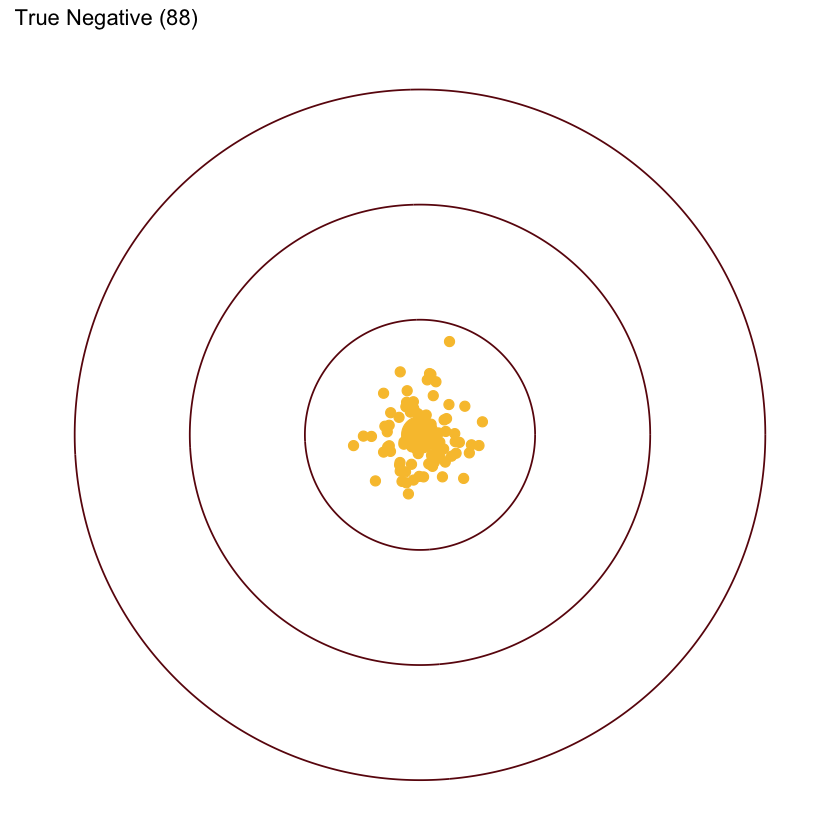

In [53]:
grid.arrange(
  p_TN
)

Warning message:
“Removed 4 rows containing missing values or values outside the scale range
(`geom_point()`).”


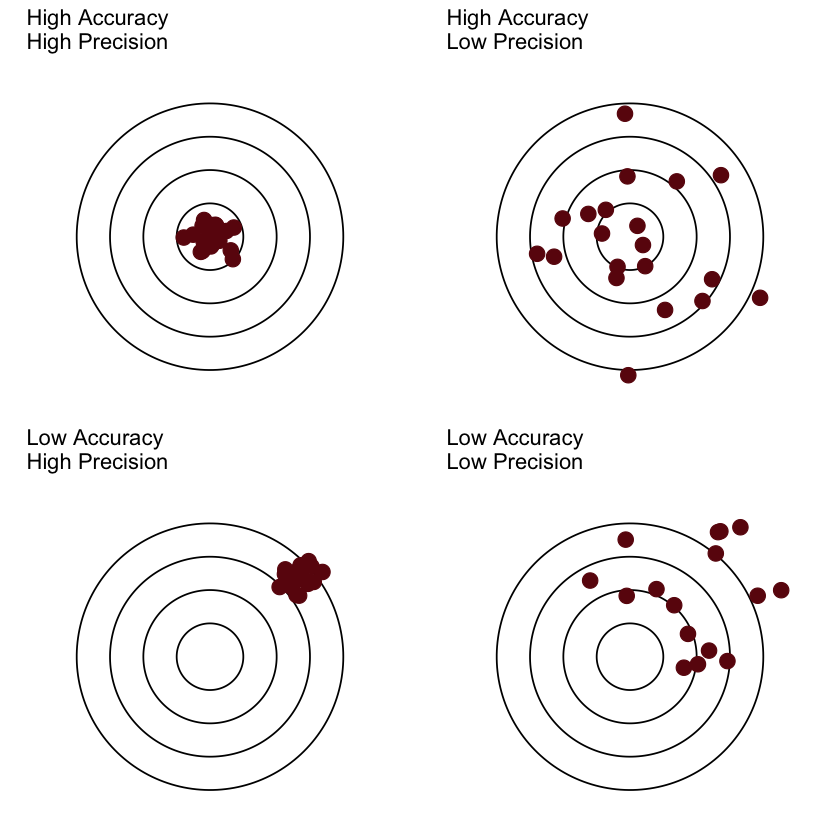

In [54]:
library(ggplot2)
library(gridExtra)

set.seed(123)

# ==========================
# Target Background
# ==========================
target_plot <- function(df, title){

  ggplot(df, aes(x, y)) +

    annotate(
      "path",
      x = cos(seq(0,2*pi,length=200))*4,
      y = sin(seq(0,2*pi,length=200))*4
    ) +

    annotate(
      "path",
      x = cos(seq(0,2*pi,length=200))*3,
      y = sin(seq(0,2*pi,length=200))*3
    ) +

    annotate(
      "path",
      x = cos(seq(0,2*pi,length=200))*2,
      y = sin(seq(0,2*pi,length=200))*2
    ) +

    annotate(
      "path",
      x = cos(seq(0,2*pi,length=200))*1,
      y = sin(seq(0,2*pi,length=200))*1
    ) +

    geom_point(
      size = 4,
      color = "#6B0D0E"
    ) +

    coord_fixed() +

    xlim(-5,5) +
    ylim(-5,5) +

    theme_void() +

    ggtitle(title)
}

# ==========================
# High Accuracy High Precision
# (Your Model)
# ==========================

ha_hp <- data.frame(
  x = rnorm(20,0,0.4),
  y = rnorm(20,0,0.4)
)

# ==========================
# High Accuracy Low Precision
# ==========================

ha_lp <- data.frame(
  x = rnorm(20,0,1.8),
  y = rnorm(20,0,1.8)
)

# ==========================
# Low Accuracy High Precision
# ==========================

la_hp <- data.frame(
  x = rnorm(20,2.5,0.4),
  y = rnorm(20,2.5,0.4)
)

# ==========================
# Low Accuracy Low Precision
# ==========================

la_lp <- data.frame(
  x = rnorm(20,2.5,1.8),
  y = rnorm(20,2.5,1.8)
)

# ==========================
# Plot
# ==========================

p1 <- target_plot(
  ha_hp,
  "High Accuracy\nHigh Precision"
)

p2 <- target_plot(
  ha_lp,
  "High Accuracy\nLow Precision"
)

p3 <- target_plot(
  la_hp,
  "Low Accuracy\nHigh Precision"
)

p4 <- target_plot(
  la_lp,
  "Low Accuracy\nLow Precision"
)

grid.arrange(
  p1,p2,p3,p4,
  ncol = 2
)